In [1]:
import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_10K_pbmc-v1_atacseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    default_assay="ATAC",
    nthreads=4,
)

Downloading bucket files: 509188706 / 509188706 complete

Downloading bytes: 509188706 / 509188706 complete

In [2]:
[clusters] = ds.list_artifacts(
    from_assay="ATAC",
    kind="cluster_labels",
    operation="run_leiden_clustering", 
    complete_only=True,
)
[umap] = ds.list_artifacts(
    from_assay="ATAC",
    kind="embedding",
    operation="run_umap", 
    complete_only=True,
)

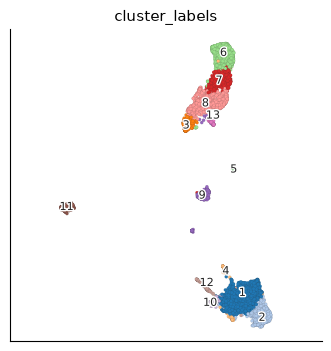

In [3]:
ds.plots.embedding(
    layout=umap,
    color_by=clusters,
    legend_loc="on_data",
)

In [4]:
annotations = scarf.cytebase.connect("scarf_docs").download_dataset(
    "annotations",
    destination="scarf_datasets",
)

ds.add_melded_assay(
    from_assay="ATAC",
    external_bed_fn=(
        f"{annotations}/human_GRCh37_gencode_v38_gene_body.bed.gz" # Use the GRCh37 BED file
    ),
    peaks_col="ids",
    renormalization=False,
    assay_label="GeneScores",
    assay_type="RNA",
)

Downloading bucket files: 4397159 / 4397159 complete

Downloading bytes: 4397159 / 4397159 complete

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


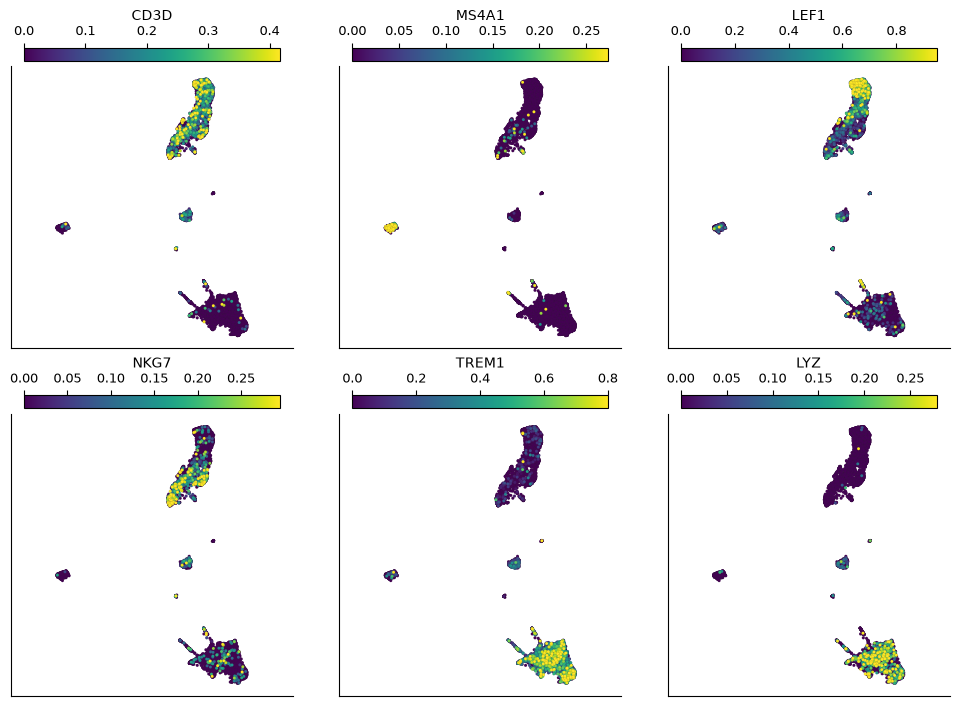

In [5]:
ds.plots.embedding(
    layout=umap,
    from_assay="GeneScores",
    color_by=["CD3D", "MS4A1", "LEF1", "NKG7", "TREM1", "LYZ"],
    clip_fraction=0.01,
    n_columns=3,
    sort_values=True,
)